In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df_path = "https://raw.githubusercontent.com/carlosfab/datasets/master/electricity_consumption/Electric_Production.csv"

In [32]:
dados = pd.read_csv(df_path)

In [33]:
dados.head()

,DATE,Value
0,01-01-1985,72.5052
1,02-01-1985,70.6720
2,03-01-1985,62.4502
3,04-01-1985,57.4714
4,05-01-1985,55.3151


In [34]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DATE    397 non-null    object 
 1   Value   397 non-null    float64
dtypes: float64(1), object(1)
memory usage: 6.3+ KB


In [35]:
dados.index = pd.to_datetime(dados.DATE, format="%m-%d-%Y")

In [36]:
dados.drop("DATE", inplace=True, axis=1)

In [37]:
dados.head()

,Value
DATE,
1985-01-01,72.5052
1985-02-01,70.6720
1985-03-01,62.4502
1985-04-01,57.4714
1985-05-01,55.3151


In [38]:
dados.loc["1985-05-01"]

Value    55.3151
Name: 1985-05-01 00:00:00, dtype: float64

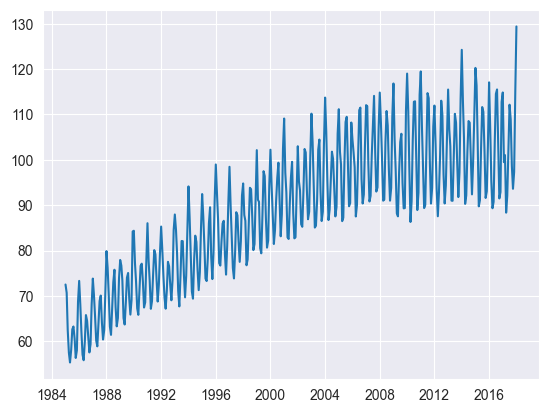

In [39]:
plt.plot(dados.index, dados.values)

In [40]:
from statsmodels.tsa.seasonal import seasonal_decompose

resultados = seasonal_decompose(dados)

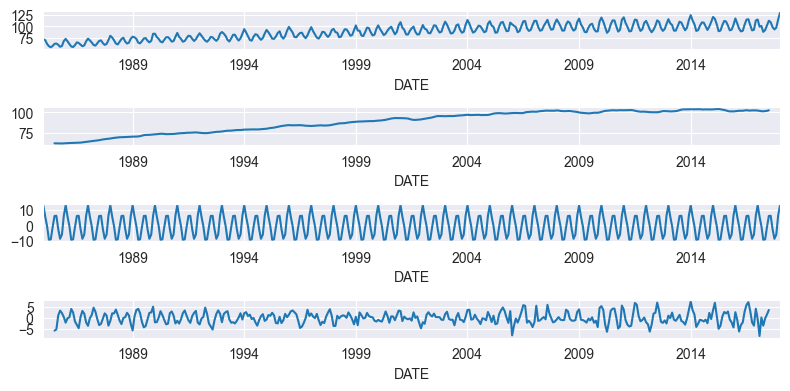

In [41]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4,1, figsize=(8,4))

resultados.observed.plot(ax=ax1)
resultados.trend.plot(ax=ax2)
resultados.seasonal.plot(ax=ax3)
resultados.resid.plot(ax=ax4)

plt.tight_layout()

In [42]:
from statsmodels.tsa.stattools import adfuller 

In [43]:
sns.set_style("darkgrid")

In [44]:
x = dados.Value.values

In [45]:
result = adfuller(x)

print("Teste adf")
print(f"Teste estatístico: {result[0]}")
print(f"P - Value: {result[1]}")
print(f"Valores críticos: {result[2]}")


for key, value in result[4].items():
    print(f"\t{key}: {value}") 

Teste adf
Teste estatístico: -2.25699035004725
P - Value: 0.18621469116586592
Valores críticos: 15
	1%: -3.4476305904172904
	5%: -2.869155980820355
	10%: -2.570827146203181


In [46]:
ma = dados.rolling(12).mean()

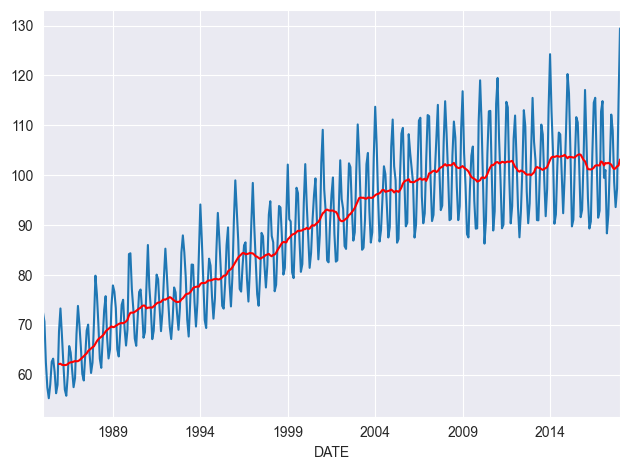

In [47]:
f, ax = plt.subplots()
dados.plot(ax=ax, legend=False)
ma.plot(ax=ax, legend=False, color="red")
plt.tight_layout()

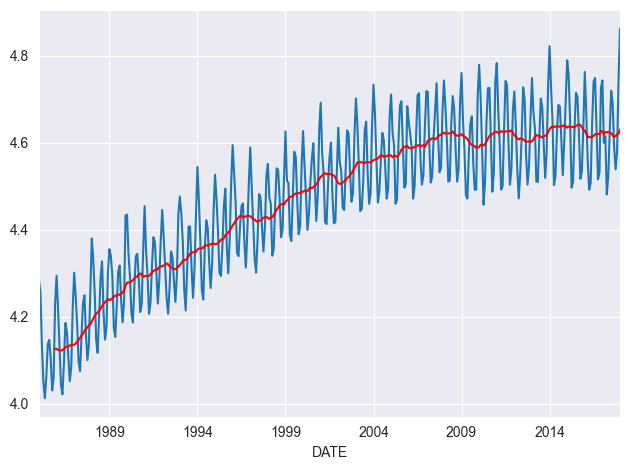

In [48]:
dados_log = np.log(dados)
ma_log = dados_log.rolling(12).mean()

f, ax = plt.subplots()
dados_log.plot(ax=ax, legend=False)
ma_log.plot(ax=ax, legend=False, color="red")
plt.tight_layout()

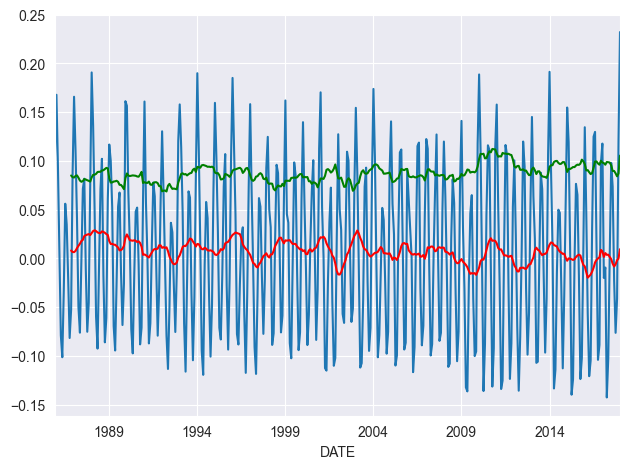

In [49]:
df_s = (dados_log - ma_log).dropna()

ma_s = df_s.rolling(12).mean()
std = df_s.rolling(12).std()

f, ax = plt.subplots()
df_s.plot(ax=ax, legend=False)
ma_s.plot(ax=ax, legend=False, color='r')
std.plot(ax=ax, legend=False, color='g')
plt.tight_layout()

In [66]:
x_s = dados_log .Value.values

result_s = adfuller(x_s)

print("Teste adf")
print(f"Teste estatístico: {result_s[0]}")
print(f"P - Value: {result_s[1]}")
print(f"Valores críticos: {result_s[2]}")


for key, value in result_s[4].items():
    print(f"\t{key}: {value}") 

Teste adf
Teste estatístico: -3.145360428107728
P - Value: 0.023373401032985245
Valores críticos: 15
	1%: -3.4476305904172904
	5%: -2.869155980820355
	10%: -2.570827146203181


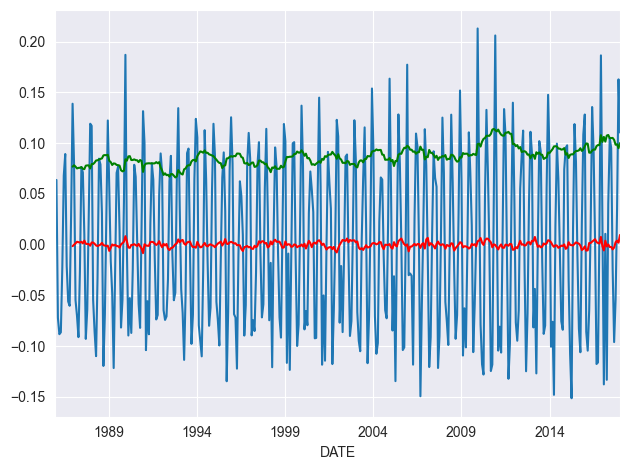

In [67]:
dados_diff = df_s.diff(1)
ma_diff = dados_diff.rolling(12).mean()

std_diff = dados_diff.rolling(12).std()

f, ax = plt.subplots()
dados_diff.plot(ax=ax, legend = False)
ma_diff.plot(ax=ax, legend = False, color="r")
std_diff.plot(ax=ax, legend = False, color="g")
plt.tight_layout()

x_diff = dados_diff.Value.dropna().values
result_diff = adfuller(x_diff)

In [68]:
from statsmodels.tsa.stattools import acf, pacf

lag_acf = acf(dados_diff, nlags=25)
lag_pacf = pacf(dados_diff, nlags=25)

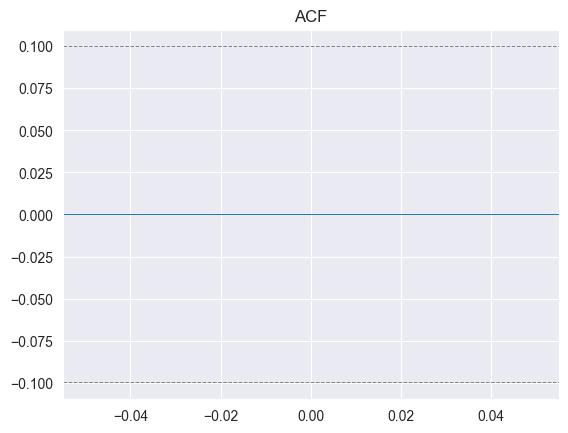

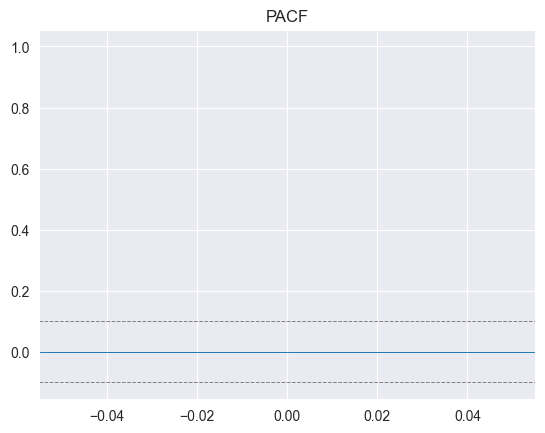

In [69]:
plt.plot(lag_acf)

plt.axhline(y=-1.96/(np.sqrt((len(dados_diff) -1))), linestyle="--", color="gray", linewidth=0.7)
plt.axhline(y=0, linewidth=0.7)
plt.axhline(y=1.96/(np.sqrt((len(dados_diff) -1))), linestyle="--", color="gray", linewidth=0.7)

plt.title("ACF")
plt.show()

plt.plot(lag_pacf)

plt.axhline(y=-1.96/(np.sqrt((len(dados_diff) -1))), linestyle="--", color="gray", linewidth=0.7)
plt.axhline(y=0, linewidth=0.7)
plt.axhline(y=1.96/(np.sqrt((len(dados_diff) -1))), linestyle="--", color="gray", linewidth=0.7)

plt.title("PACF")
plt.show()